In [ ]:
# 🔹 Cell 1: Install Dependencies
# This cell installs all required packages for the Multi-RAG system.
# Includes LangChain ecosystem, FAISS for vector search, Sentence Transformers for embeddings,
# scikit-learn for TF-IDF keyword search, PyPDF for document loading, and transformers for local LLM.
# Also installs Graphviz for the final architecture diagram.
!pip install -q langchain langchain-community langchain-core langchain-text-splitters faiss-cpu pypdf sentence-transformers scikit-learn transformers accelerate
!apt-get install -y graphviz > /dev/null 2>&1
!pip install -q graphviz


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.0 which is incompatible.
✅ All dependencies installed successfully!


In [ ]:
# 🔹 Cell 2: Imports
# Core imports for the entire Multi-RAG pipeline.
# All libraries are imported here so subsequent cells can run independently (Colab state is preserved).
import os
import torch
from google.colab import files
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.llms import HuggingFacePipeline
from langchain_core.prompts import PromptTemplate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import pipeline
import graphviz
from IPython.display import display, Image
import warnings
warnings.filterwarnings("ignore")
print(" All imports loaded successfully!")

✅ All imports loaded successfully!


In [ ]:
# 🔹 Cell 3: File Upload Cell (Colab upload)
# Upload your PDF document here. The system supports any single PDF file.
# After upload, the filename is automatically captured for the next cells.
print(" Please upload your PDF document...")
uploaded = files.upload()

# Automatically get the uploaded PDF (assumes one file is uploaded)
if uploaded:
    pdf_filename = list(uploaded.keys())[0]
    print(f" PDF uploaded successfully: {pdf_filename}")
else:
    print(" No file uploaded. Please run this cell again and upload a PDF.")

 Please upload your PDF document...


Saving RAG_Research_Paper.pdf to RAG_Research_Paper.pdf
 PDF uploaded successfully: RAG_Research_Paper.pdf


In [ ]:
# 🔹 Cell 4: PDF Text Extraction Cell
# Loads the uploaded PDF and extracts raw text using LangChain's PyPDFLoader.
# This is the first step of the ingestion pipeline.
loader = PyPDFLoader(pdf_filename)
docs = loader.load()

# Combine all pages into a single text block for cleaning
raw_text = "\n".join([doc.page_content for doc in docs])
print(f" PDF extracted successfully! Total pages: {len(docs)} | Total characters: {len(raw_text)}")

 PDF extracted successfully! Total pages: 21 | Total characters: 109954


In [ ]:
# 🔹 Cell 5: Text Cleaning + Query Preprocessing Cell
# Cleans the extracted text (removes extra whitespace, newlines, special characters).
# Also defines a query preprocessor for consistency in retrieval.
def clean_text(text):
    """Clean and normalize text for better chunking and retrieval."""
    text = text.replace('\n', ' ').replace('\t', ' ')
    text = ' '.join(text.split())  # Remove extra spaces
    text = text.strip()
    return text

def preprocess_query(query):
    """Basic query preprocessing (can be extended with stemming/lemmatization)."""
    return query.strip()

# Apply cleaning to the full document text
full_text = clean_text(raw_text)
print(" Text cleaning completed!")
print(f"Cleaned text preview (first 300 chars): {full_text[:300]}...")

 Text cleaning completed!
Cleaned text preview (first 300 chars): 1 Retrieval-Augmented Generation for Large Language Models: A Survey Yunfan Gaoa, Yun Xiong b, Xinyu Gao b, Kangxiang Jia b, Jinliu Pan b, Yuxi Bi c, Yi Dai a, Jiawei Sun a, Meng Wangc, and Haofen Wang a,c aShanghai Research Institute for Intelligent Autonomous Systems, Tongji University bShanghai K...


In [ ]:
# 🔹 Cell 6: Chunking Cell
# Chunks the cleaned text using fixed-size + overlap strategy.
# RecursiveCharacterTextSplitter ensures semantically coherent chunks.
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,      # Fixed size: ~800 characters per chunk (adjustable)
    chunk_overlap=150,   # Overlap for context continuity
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks = text_splitter.split_text(full_text)
print(f" Chunking completed! Created {len(chunks)} overlapping chunks.")
print(f"Example chunk (first 200 chars): {chunks[0][:200]}...")

 Chunking completed! Created 171 overlapping chunks.
Example chunk (first 200 chars): 1 Retrieval-Augmented Generation for Large Language Models: A Survey Yunfan Gaoa, Yun Xiong b, Xinyu Gao b, Kangxiang Jia b, Jinliu Pan b, Yuxi Bi c, Yi Dai a, Jiawei Sun a, Meng Wangc, and Haofen Wan...


In [ ]:
# 🔹 Cell 7: Embedding Generation Cell
# Loads the Sentence-Transformer embedding model (lightweight and high-performance).
# This model generates dense vectors for semantic (vector) retrieval.
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={'device': 'cuda' if torch.cuda.is_available() else 'cpu'}
)
print(" Embedding model loaded successfully!")
print(f"Using device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Embedding model loaded successfully!
Using device: CPU


In [ ]:
# 🔹 Cell 8: FAISS Vector Store Cell
# Builds the FAISS vector database from chunks + embeddings.
# This enables fast vector-based (semantic) similarity search.
vectorstore = FAISS.from_texts(
    texts=chunks,
    embedding=embeddings
)
print(" FAISS vector store created successfully!")
print(f"Total vectors in index: {vectorstore.index.ntotal}")

 FAISS vector store created successfully!
Total vectors in index: 171


In [ ]:
# 🔹 Cell 9: Keyword Retrieval Cell
# Builds a TF-IDF vectorizer on the chunks for sparse keyword-based retrieval (BM25-like).
# This complements vector search for exact term matching.
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform(chunks)

def keyword_search(query, top_k=6):
    """Perform TF-IDF keyword search and return (chunk, similarity_score) pairs."""
    query_vec = tfidf_vectorizer.transform([preprocess_query(query)])
    similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_indices = similarities.argsort()[-top_k:][::-1]
    results = [(chunks[i], float(similarities[i])) for i in top_indices]
    return results

print(" Keyword (TF-IDF) retrieval model ready!")

 Keyword (TF-IDF) retrieval model ready!


In [ ]:
# 🔹 Cell 10: Hybrid Retrieval Cell
# Combines results from vector search (FAISS) and keyword search (TF-IDF).
# Returns raw results from both retrievers for downstream re-ranking.
def hybrid_retrieve(query, vector_k=6, keyword_k=6):
    """Hybrid retrieval: Vector (semantic) + Keyword (sparse) results."""
    # Vector search (FAISS) - returns (Document, distance)
    vector_results = vectorstore.similarity_search_with_score(query, k=vector_k)

    # Keyword search (TF-IDF) - returns (text, similarity_score)
    keyword_results = keyword_search(query, keyword_k)

    # Debug logging
    print(" VECTOR RESULTS (top 3):")
    for i, (doc, score) in enumerate(vector_results[:3]):
        print(f"  {i+1}. Score: {score:.4f} | {doc.page_content[:150]}...")
    print(" KEYWORD RESULTS (top 3):")
    for i, (text, score) in enumerate(keyword_results[:3]):
        print(f"  {i+1}. Score: {score:.4f} | {text[:150]}...")

    return vector_results, keyword_results

print(" Hybrid retrieval function ready!")

 Hybrid retrieval function ready!


In [ ]:
# 🔹 Cell 11: Context Re-ranking Cell
# Re-ranks combined chunks using a weighted score (vector similarity + keyword relevance).
# Selects the top-k most relevant chunks to reduce noise and hallucinations.
def rerank_chunks(vector_results, keyword_results, top_k=5):
    """Re-rank hybrid results with combined scoring."""
    chunk_scores = {}

    # Process vector results (convert distance to similarity: higher = better)
    for doc, dist in vector_results:
        text = doc.page_content
        vector_sim = 1.0 / (1.0 + dist)  # Normalize distance to [0,1] similarity
        chunk_scores[text] = {'vector_sim': vector_sim, 'keyword_sim': 0.0}

    # Process keyword results
    for text, kw_sim in keyword_results:
        if text in chunk_scores:
            chunk_scores[text]['keyword_sim'] = kw_sim
        else:
            chunk_scores[text] = {'vector_sim': 0.0, 'keyword_sim': kw_sim}

    # Combined score (70% vector + 30% keyword - tunable)
    for text in chunk_scores:
        scores = chunk_scores[text]
        chunk_scores[text]['combined'] = 0.7 * scores['vector_sim'] + 0.3 * scores['keyword_sim']

    # Sort and select top-k
    sorted_chunks = sorted(
        chunk_scores.items(),
        key=lambda x: x[1]['combined'],
        reverse=True
    )
    top_chunks = [text for text, _ in sorted_chunks[:top_k]]

    # Debug logging
    print(f" Re-ranking completed! Selected top-{top_k} chunks.")
    print(" TOP RANKED CHUNKS (preview):")
    for i, chunk in enumerate(top_chunks[:3]):
        print(f"  {i+1}. Score: {chunk_scores[chunk]['combined']:.4f} | {chunk[:180]}...")

    return top_chunks

print(" Context re-ranking function ready!")

 Context re-ranking function ready!


In [ ]:
# 🔹 Cell 12: Prompt Template Cell
# Strict system prompt designed to minimize hallucinations.
# Enforces "answer ONLY from context" rule for Responsible AI compliance.
prompt_template = """
You are an expert AI assistant specialized in accurate, context-grounded responses.

STRICT RULES:
- Answer ONLY using the information provided in the context below.
- If the answer is not present in the context, respond with: "I don't have enough information in the provided context to answer this question."
- Do NOT hallucinate, invent facts, or use external knowledge.
- Be concise, factual, and direct.

Context:
{context}

Question: {question}

Answer:
"""

prompt = PromptTemplate(
    template=prompt_template,
    input_variables=["context", "question"]
)

print("Strict anti-hallucination prompt template created!")

Strict anti-hallucination prompt template created!


In [ ]:
# 🔹 Cell 13: Multi-RAG Pipeline Cell
# Full end-to-end Multi-RAG pipeline: Hybrid Retrieval → Re-ranking → Prompt → LLM.
# This is the core production-quality orchestration.

# Initialize local LLM (Flan-T5-small - fast, instruction-tuned, no API key required)
llm_pipeline = pipeline(
    "text-generation", # Changed from "text2text-generation" to "text-generation"
    model="google/flan-t5-small",
    max_new_tokens=512,
    temperature=0.0,
    do_sample=False,
    device=0 if torch.cuda.is_available() else -1
)
llm = HuggingFacePipeline(pipeline=llm_pipeline)

def multi_rag_pipeline(query, top_k=5):
    """Complete Multi-RAG pipeline with hybrid retrieval + re-ranking + strict prompting."""
    print(f"\n Processing query: '{query}'")

    # Step 1: Hybrid Retrieval
    vector_results, keyword_results = hybrid_retrieve(query)

    # Step 2: Re-ranking
    ranked_chunks = rerank_chunks(vector_results, keyword_results, top_k=top_k)

    # Step 3: Build context
    context = "\n\n---\n\n".join(ranked_chunks)

    # Step 4: Format prompt
    formatted_prompt = prompt.format(context=context, question=query)

    # Step 5: Generate answer with LLM
    answer = llm.invoke(formatted_prompt)

    # Debug: Show final ranked chunks
    print("\n FINAL RANKED CHUNKS SENT TO LLM:")
    for i, chunk in enumerate(ranked_chunks):
        print(f"  Chunk {i+1}: {chunk[:250]}...")

    return answer.strip(), ranked_chunks

print(" Full Multi-RAG pipeline ready! (Local LLM initialized)")

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLl

 Full Multi-RAG pipeline ready! (Local LLM initialized)


In [30]:
# 🔹 Cell 14: Query Execution Cell
# Interactive query execution with full debug output.
# Prints retrieved chunks + final answer.
# Run this cell repeatedly to test different queries.

query = input(" Enter your question about the PDF: ").strip()

if query:
    final_answer, retrieved_chunks = multi_rag_pipeline(query)
    print("\n" + "="*80)
    print(" FINAL ANSWER:")
    print(final_answer)
    print("="*80)
    print(f"\n Total chunks retrieved and re-ranked: {len(retrieved_chunks)}")
else:
    print(" Please enter a valid query.")

 Enter your question about the PDF: technology tree

 Processing query: 'technology tree'
 VECTOR RESULTS (top 3):
  1. Score: 1.2950 | . 2) Simplification - making RAG easier to use to reduce the 11https://github.com/weaviate/Verba 12https://aws.amazon.com/cn/kendra/ 16 Fig. 6. Summar...
  2. Score: 1.3848 | . The development of the RAG ecosystem is greatly impacted by the progression of its technical stack. Key tools like LangChain and LLamaIndex have qui...
  3. Score: 1.4362 | . Other technologies like HayStack, Meltano, and Cohere Coral are also gaining attention for their unique contributions to the field. In addition to A...
 KEYWORD RESULTS (top 3):
  1. Score: 0.2897 | . By referencing external knowledge, RAG effectively reduces the problem of generating factually incorrect content. Its integration into LLMs has resu...
  2. Score: 0.1983 | . 2) Simplification - making RAG easier to use to reduce the 11https://github.com/weaviate/Verba 12https://aws.amazon.com/cn/kendra/ 16 Fi

Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



📋 FINAL RANKED CHUNKS SENT TO LLM:
  Chunk 1: . 2) Simplification - making RAG easier to use to reduce the 11https://github.com/weaviate/Verba 12https://aws.amazon.com/cn/kendra/ 16 Fig. 6. Summary of RAG ecosystem initial learning curve. 3) Specialization - optimizing RAG to better serve produc...
  Chunk 2: . The process involves iteratively refining search queries based on the results obtained from previous searches. Recursive Retrieval aims to enhance the search experience by gradu- ally converging on the most pertinent information through a feedback ...
  Chunk 3: . The development of the RAG ecosystem is greatly impacted by the progression of its technical stack. Key tools like LangChain and LLamaIndex have quickly gained popularity with the emergence of ChatGPT, providing extensive RAG- related APIs and beco...
  Chunk 4: . Other technologies like HayStack, Meltano, and Cohere Coral are also gaining attention for their unique contributions to the field. In addition to AI-focuse

Multi-RAG architecture diagram generated and saved as 'multi_rag_pipeline.png'


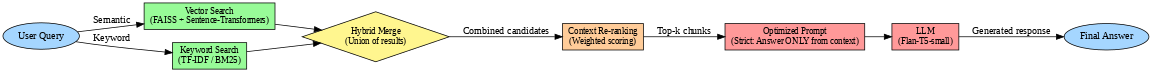


 Architecture Summary:
Query → Vector + Keyword → Hybrid Merge → Re-ranking → Strict Prompt → LLM → Answer


In [31]:
# 🔹 Final Cell: Generate Multi-RAG Architecture Image
# Creates and displays a clean, professional diagram of the full Multi-RAG system.
# Saves as "multi_rag_pipeline.png" and shows it inline (production-quality visualization).

dot = graphviz.Digraph(comment='Multi-RAG Architecture', format='png')
dot.attr(rankdir='LR', size='12,8', bgcolor='white', fontname='Arial')

# Nodes with labels and styling
dot.node('Q', 'User Query', shape='ellipse', style='filled', fillcolor='#A5D6FF', fontsize='14', fontcolor='black')
dot.node('V', 'Vector Search\n(FAISS + Sentence-Transformers)', shape='box', style='filled', fillcolor='#98FB98', fontsize='12')
dot.node('K', 'Keyword Search\n(TF-IDF / BM25)', shape='box', style='filled', fillcolor='#98FB98', fontsize='12')
dot.node('H', 'Hybrid Merge\n(Union of results)', shape='diamond', style='filled', fillcolor='#FFF68F', fontsize='12')
dot.node('R', 'Context Re-ranking\n(Weighted scoring)', shape='box', style='filled', fillcolor='#FFCC99', fontsize='12')
dot.node('P', 'Optimized Prompt\n(Strict: Answer ONLY from context)', shape='box', style='filled', fillcolor='#FF9999', fontsize='12')
dot.node('L', 'LLM\n(Flan-T5-small)', shape='box', style='filled', fillcolor='#FF9999', fontsize='12')
dot.node('A', 'Final Answer', shape='ellipse', style='filled', fillcolor='#A5D6FF', fontsize='14', fontcolor='black')

# Edges with labels
dot.edge('Q', 'V', label='Semantic')
dot.edge('Q', 'K', label='Keyword')
dot.edge('V', 'H')
dot.edge('K', 'H')
dot.edge('H', 'R', label='Combined candidates')
dot.edge('R', 'P', label='Top-k chunks')
dot.edge('P', 'L')
dot.edge('L', 'A', label='Generated response')

# Render and display
dot.render('multi_rag_pipeline', cleanup=True, view=False)
print("Multi-RAG architecture diagram generated and saved as 'multi_rag_pipeline.png'")

# Display in Colab
display(Image('multi_rag_pipeline.png'))
print("\n Architecture Summary:")
print("Query → Vector + Keyword → Hybrid Merge → Re-ranking → Strict Prompt → LLM → Answer")